## Frequential analysis of events

In [1]:
from pyspark.sql import functions as F
from utils.ml import data_dir, spark, prepare_data_pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/20 04:50:50 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/20 04:50:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 04:50:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df.show(5)

+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|year|month|day|order|country|session ID|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|2008|    4|  1|    1|     29|         1|                     1|                    A13|     1|       5|                1|   28|      2|   1|
|2008|    4|  1|    2|     29|         1|                     1|                    A16|     1|       6|                1|   33|      2|   1|
|2008|    4|  1|    3|     29|         1|                     2|                     B4|    10|       2|                1|   52|      1|   1|
|2008|    4|  1|    4|     29|         1|                     2|                    B17|     6|       6|                2|   38|      2|   1|
|2008|

## Constructing tokens

Token information is everything except "year", "month", "day", "session ID", "order", and for now we will ignore the country

In [3]:
to_omit = ["year", "month", "day", "session ID", "order", "country"]
token_cols = [col for col in df.columns if col not in to_omit]
print(token_cols)

['page 1 (main category)', 'page 2 (clothing model)', 'colour', 'location', 'model photography', 'price', 'price 2', 'page']


In [4]:
tokens = df.select(*token_cols).drop_duplicates()
print("Total amount of unique tokens: ", tokens.count())

Total amount of unique tokens:  218


### Index tokens and join index

In [5]:
tokens = tokens.withColumn("id", F.monotonically_increasing_id())
df = df.join(tokens, on = token_cols, how="left")
df.show(5)

+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+----+-----+---+-----+-------+----------+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|year|month|day|order|country|session ID| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+----+-----+---+-----+-------+----------+---+
|                     1|                    A13|     1|       5|                1|   28|      2|   1|2008|    4|  1|    1|     29|         1|197|
|                     1|                    A16|     1|       6|                1|   33|      2|   1|2008|    4|  1|    2|     29|         1|149|
|                     2|                     B4|    10|       2|                1|   52|      1|   1|2008|    4|  1|    3|     29|         1| 51|
|                     2|                    B17|     6|       6|                2|   38|      2|   1|2008|    4|  1|    4|  

### Get frequencies

In [6]:
freq = df.groupBy("id").count()
print("Sum verification: ", freq.select(F.sum(freq["count"])).collect()[0][0])

Sum verification:  165474


### Zipf's fitting and Plotting

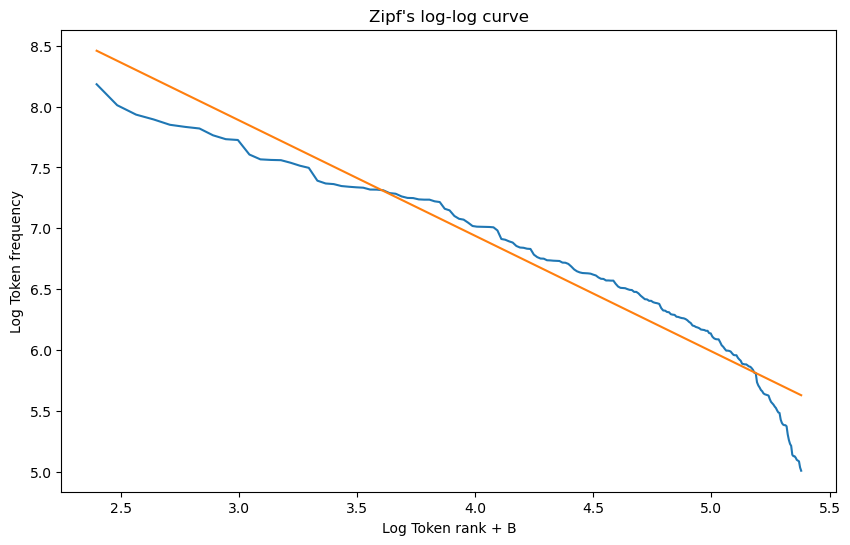

Zipf's fit R-squared:  0.9230596509189264
Zipf's fit MSE:  0.0382498080805847
Zipf's fit Explained Variance:  0.4588860580275158
C estimate: 45791.55
Alpha estimate: 0.95


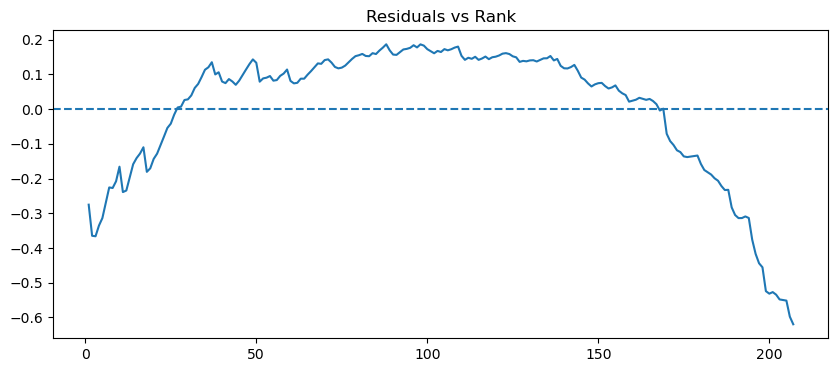

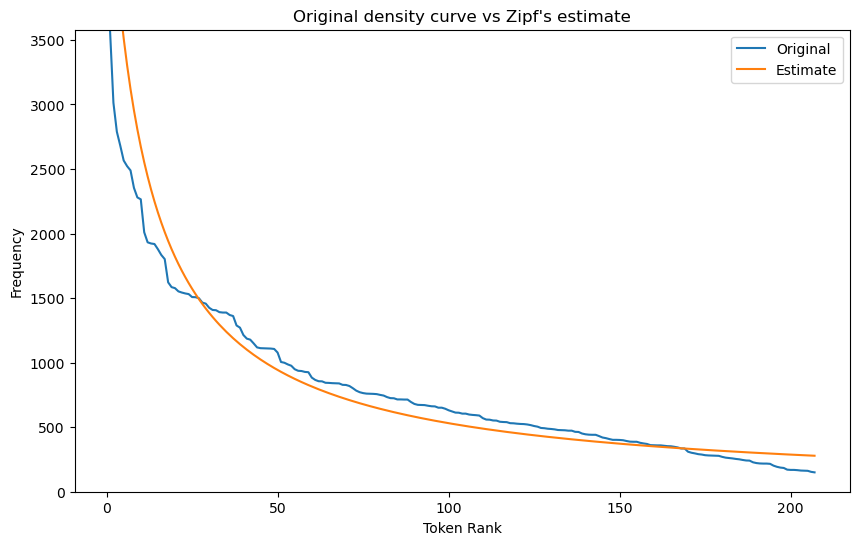

In [9]:
import numpy as np
from pyspark.sql import DataFrame
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.pipeline import Pipeline

def fit_zipfs(freqs: DataFrame, B =  10, frequency_col = "count", id_col = "id", drop_bottom = 0, drop_top=0):
    def zipfs_f(ranks: DataFrame, C, alpha):
        preds = ranks.withColumn("density_pred", C / (F.col("rank") + F.lit(B))**alpha)
        return preds
    freqz = freqs.orderBy(frequency_col, ascending = False)
    size = freqz.count()
    freqz = freqz.withColumn("rank", F.monotonically_increasing_id() + 1)
    if drop_top != 0 or drop_bottom != 0:
        freqz = freqz.filter((F.col('rank') < (size - drop_bottom)) & (F.col('rank') > drop_top)).withColumn("rank", F.monotonically_increasing_id() + 1)

    freqz = freqz.withColumn("log_ranks", F.log(F.col("rank") + F.lit(B)))
    freqz = freqz.withColumn("log_freqs", F.log(frequency_col))

    #linear log-log fit
    va_ranks = VectorAssembler(inputCols=["log_ranks"], outputCol="log_ranks_v")
    reg_zipf = LinearRegression(featuresCol="log_ranks_v", labelCol="log_freqs", predictionCol="estimate", regParam=1e-8)

    zipfs_pipeline = Pipeline(stages = [va_ranks, reg_zipf]).fit(freqz)
    zipfs_model = zipfs_pipeline.stages[-1]

    coefs = zipfs_model.coefficients.toArray()
    log_C = zipfs_model.intercept
    C = np.exp(log_C)
    alpha = -coefs[0] 

    preds = zipfs_pipeline.transform(freqz).select(id_col, "rank", "log_ranks", "log_freqs", frequency_col, "estimate")
    preds_pd = preds.toPandas()

    plt.figure(figsize=(10, 6))
    plt.plot(preds_pd["log_ranks"], preds_pd["log_freqs"])
    plt.plot(preds_pd["log_ranks"], preds_pd["estimate"])
    plt.title("Zipf's log-log curve")
    plt.ylabel("Log Token frequency")
    plt.xlabel("Log Token rank + B")
    plt.show()
    print("Zipf's fit R-squared: ", zipfs_model.summary.r2)
    print("Zipf's fit MSE: ", zipfs_model.summary.meanSquaredError)
    print("Zipf's fit Explained Variance: ", zipfs_model.summary.explainedVariance)
    print(f"C estimate: {C:.2f}")
    print(f"Alpha estimate: {alpha:.2f}")

    preds_pd["residual"] = preds_pd["log_freqs"] - preds_pd["estimate"]

    plt.figure(figsize=(10, 4))
    plt.plot(preds_pd["rank"], preds_pd["residual"])
    plt.axhline(0, linestyle="--")
    plt.title("Residuals vs Rank")
    plt.show()

    final = zipfs_f(preds, C, alpha=alpha)
    density_pred = final.select("density_pred").toPandas()
    plt.figure(figsize=(10, 6))
    plt.plot(preds_pd["rank"], preds_pd[frequency_col], label = "Original")
    plt.title("Original density curve vs Zipf's estimate")
    plt.plot(preds_pd["rank"], density_pred["density_pred"], label = "Estimate")
    plt.legend()
    plt.ylim((0,preds_pd[frequency_col].max()))
    plt.ylabel("Frequency")
    plt.xlabel("Token Rank")
    plt.show()
    return final

freqz = fit_zipfs(freq, drop_top=0, drop_bottom=10)

Adjust above - drop bottom or drop top to change the basis for selection top and worst products

In [8]:
freqz = freqz.join(tokens.select("id","page 2 (clothing model)"), on = "id", how = "left")
top_10_products = freqz.where(F.col("rank") <= 10)
worst_10_products = freqz.where(F.col("rank") >= (freqz.count() - 10))
top_10_products.show()
worst_10_products.show()

+---+----+------------------+------------------+-----+-----------------+------------------+-----------------------+
| id|rank|         log_ranks|         log_freqs|count|         estimate|      density_pred|page 2 (clothing model)|
+---+----+------------------+------------------+-----+-----------------+------------------+-----------------------+
| 51|   1|2.3978952727983707| 8.182838710766026| 3579|8.836647306065734|6881.8810780600825|                     B4|
|212|   2|2.4849066497880004|   8.0106915391303| 3013| 8.73301066379824| 6204.379321064863|                     A2|
| 62|   3|2.5649493574615367| 7.933438387627489| 2789|8.637674194611312| 5640.196558097351|                    A11|
| 86|   4|2.6390573296152584| 7.893945138235959| 2681|8.549406410960675| 5163.688408446718|                     P1|
| 76|   5|  2.70805020110221| 7.850103545175582| 2566|8.467231070348003|  4756.32728368803|                    B10|
|191|   6| 2.772588722239781|7.8328075165248645| 2522|8.390361172881553|